# House Prices Prediction
Kaggle соревнование. Цель - предсказать цены на дома.<br><br>
Результаты:
| # | Изменение | Kaggle Score | Место |
|---|-----------|:------------:|:-----:|
| 1 | CatBoost baseline | 0.12894 | 1617 / 5015 |
| 2 | Обучение на всём трейне | 0.12768 | 1401 / 5015 |
| 3 | CatBoost + CV in Optuna | 0.12768 | 1405 / 5039 |
| 4 | Ансамбль 0.8×CB + 0.2×LGBM | 0.12362 | 817 / 5042 |
| 5 | CB + EN + 5 признаков (NaN баг) | 0.15062 | — |
| 6 | CB + EN, bugfix | 0.15062 | — |
| 7 | Только CatBoost (Optuna 5-fold) | 0.12409 | — |
| 8 | Только CatBoost (Optuna 3-fold) | 0.12453 | — |

## Содержание
- [1. Exploratory Data Analysis](#eda)
- [2. Feature Engineering & Preprocessing](#preprocessing)
- [3. Baseline — XGBoost (default params)](#baseline)
- [4. Основная модель — CatBoost/LightGBM с тюнингом](#gb)
  - [4.1. CatBoost w/o Optuna](#cb-base)
  - [4.2. CatBoost SHAP](#cb-shap)
  - [4.3. CatBoost w/ Optuna](#cb-optuna)
  - [4.4. LightGBM w/o Optuna](#lgbm-base)
  - [4.5. LightGBM w/ Optuna](#lgbm-optuna)
- [5. Ансамбль из CatBoost + LightGBM](#ensemble)
- [6. Submission](#submission)

In [241]:
import lightgbm as lgb
import optuna
import shap
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from lightgbm import LGBMRegressor
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import RobustScaler

In [242]:
train_df = pd.read_csv('data/train.csv', index_col='Id')
test_df = pd.read_csv('data/test.csv', index_col='Id')

## 1. Exploratory Data Analysis (EDA)
<a id="eda"></a>

In [243]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

Семантический анализ показал:
1. MSSubClass - категориальный признак, записанный в числовом типе данных
2. Некоторые фичи имеют "NA" как категорию, придется обработать такие кейсы

In [244]:
train_df['MSSubClass'] = train_df['MSSubClass'].astype('str')
test_df['MSSubClass'] = test_df['MSSubClass'].astype('str')

num_ftrs = [i for i in train_df.drop(columns=['SalePrice']) 
            if train_df[i].dtype in [np.int64, np.float64]]

NA_category = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
               'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
               'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

train_df[NA_category] = train_df[NA_category].fillna("NA")
test_df[NA_category] = test_df[NA_category].fillna("NA")

cat_ftrs = [i for i in train_df if train_df[i].dtype=='str']

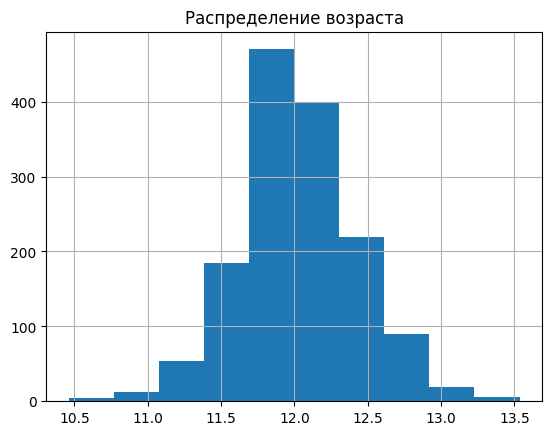

In [245]:
train_df['SalePrice'] = np.log(train_df['SalePrice'])
train_df['SalePrice'].hist()
plt.title('Распределение возраста')
plt.show()

Необходимость логарифмирования таргета возникает из-за того, что метрикой для оценки результата является RMSE на логарифмах. После преобразования распределение приближается к нормальному. Перед сабмитом важно будет провести экспоненцирование таргета (обратную логарифмированию операцию).

### Числовые признаки

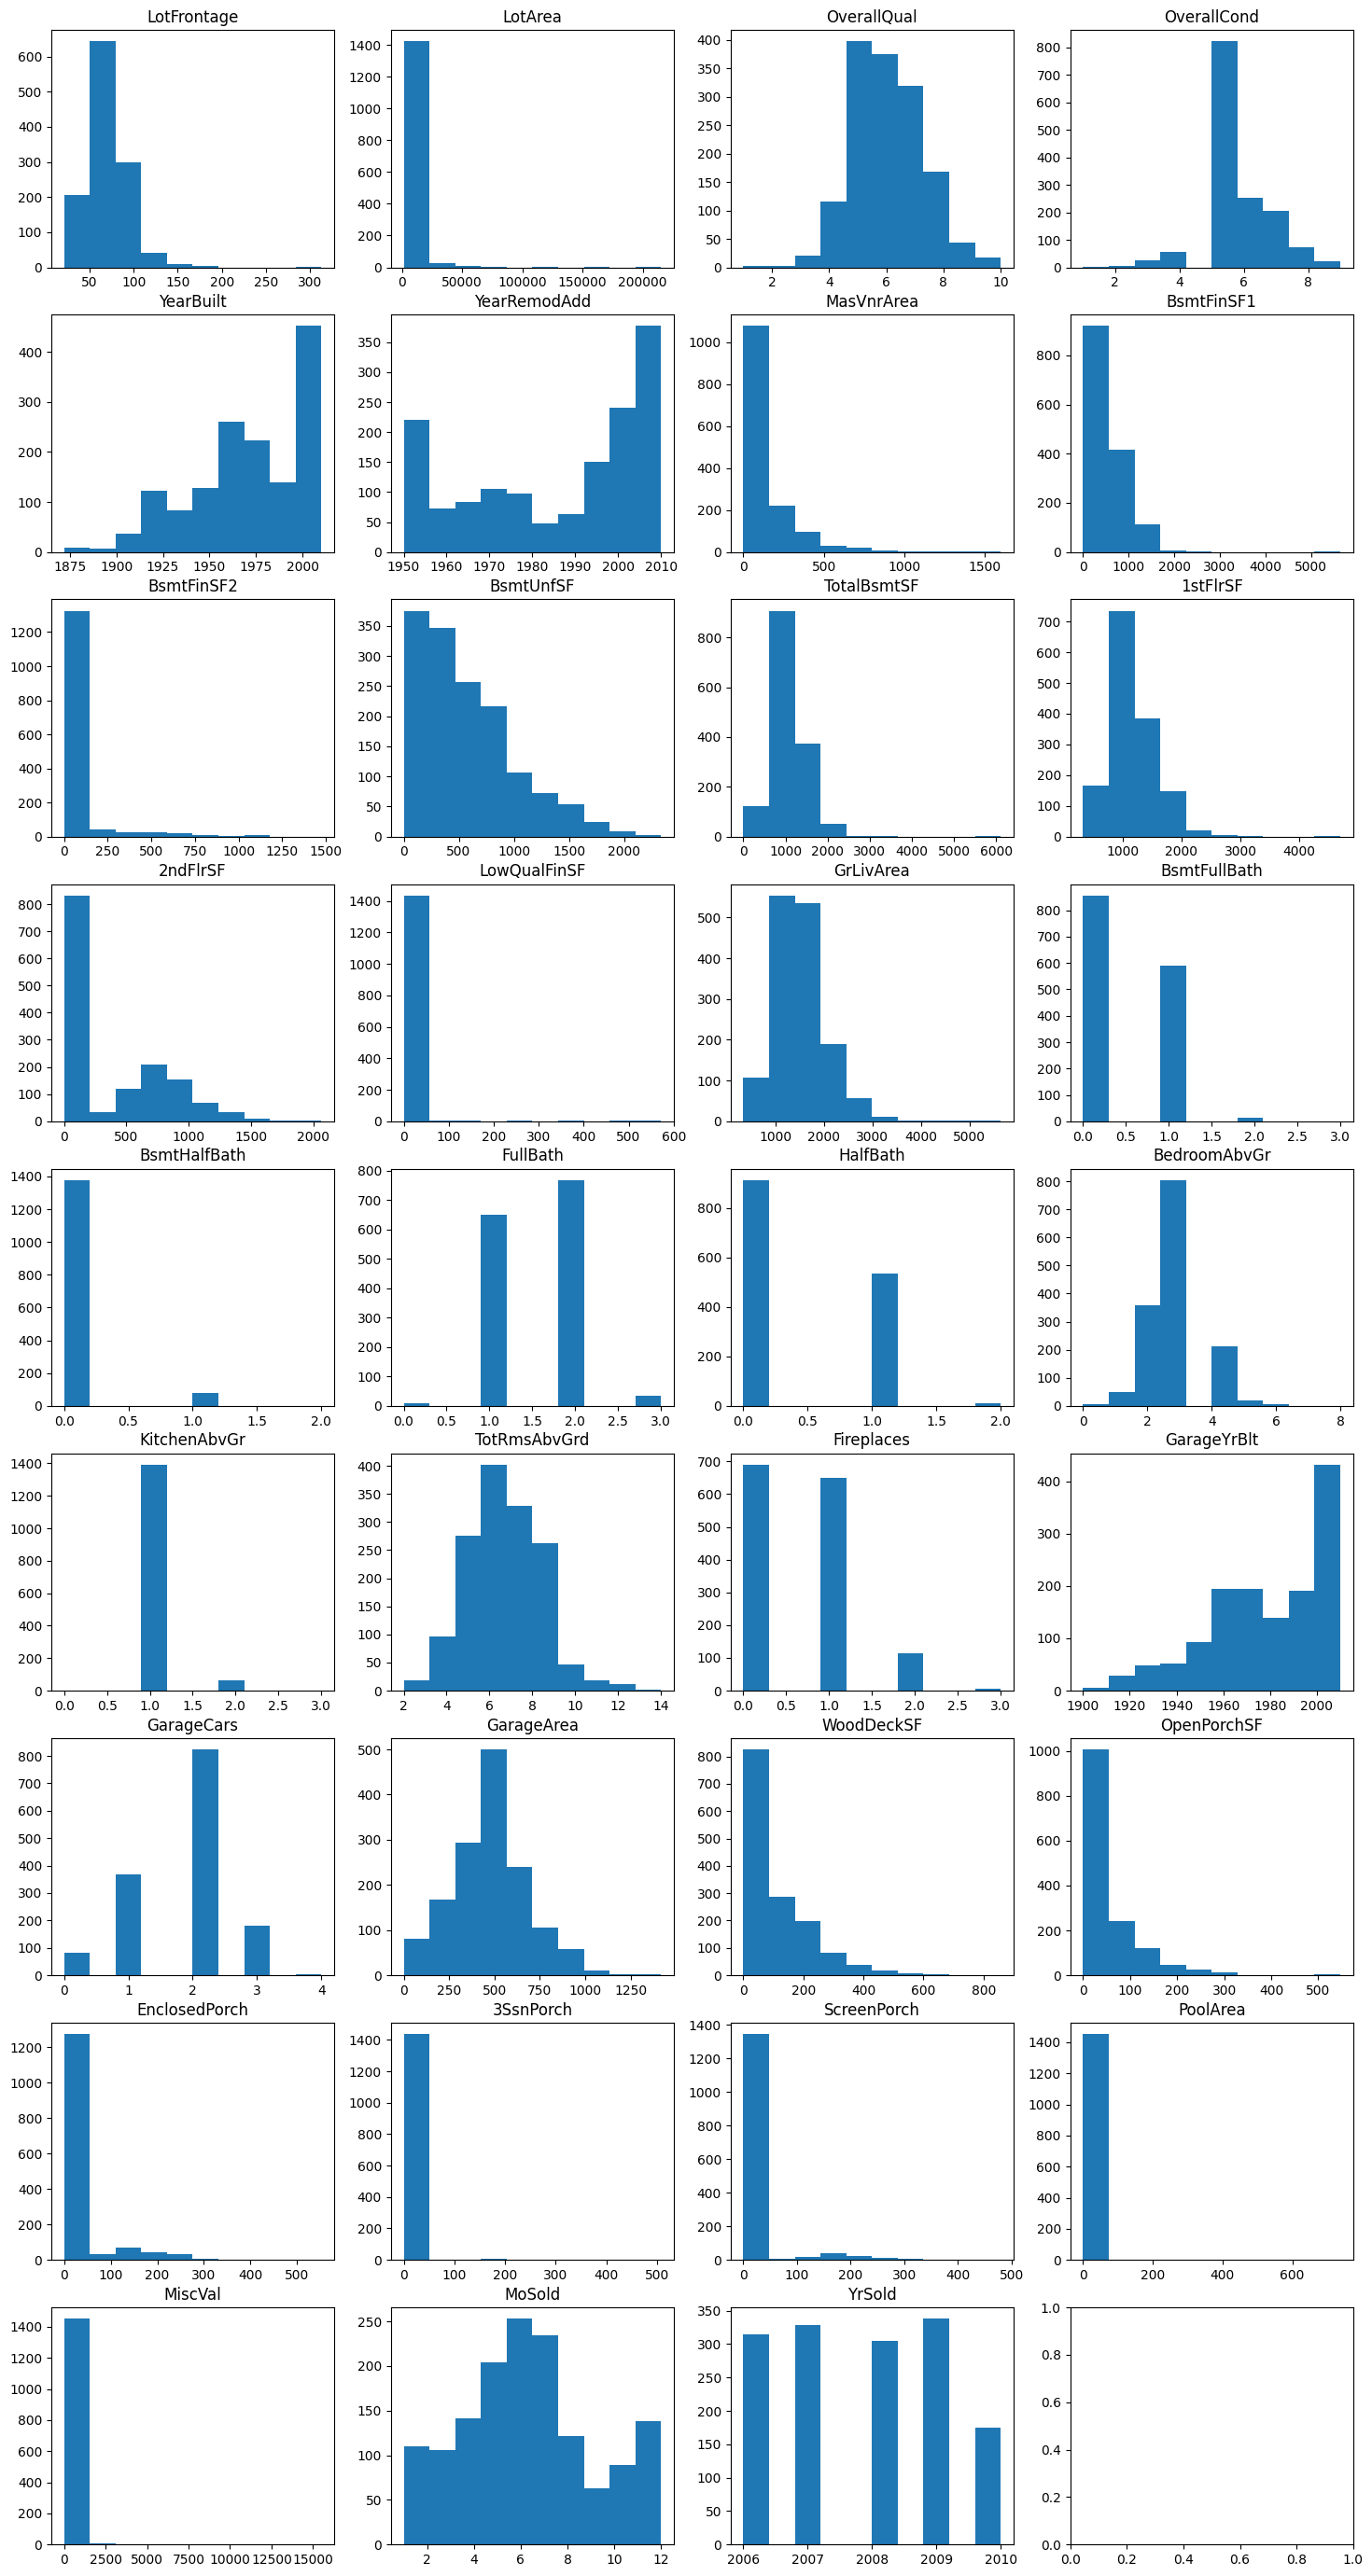

In [246]:
fig, axes = plt.subplots(9, 4, figsize=(18,35))

for ax, col in zip(axes.flatten(), num_ftrs):
    ax.hist(train_df[col])
    ax.set_title(col)

plt.tight_layout
plt.show()

Есть признаки с несбалансированным (zero-inflated) распределением: LotArea, BsmtFinSF2, MasVnrArea, TotalBsmtSF, LowQualFinSF, BsmtHalfBath, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, MiscVal. Для деревьев это не проблема — они инвариантны к монотонным преобразованиям и находят оптимальные пороги самостоятельно. PoolArea интересен как бинарный признак (есть/нет бассейн) — идея для feature engineering.

In [247]:
corr = train_df.select_dtypes(include='number').corr()

corr['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.817184
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489449
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355878
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209044
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057329
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePrice, dtype: float64

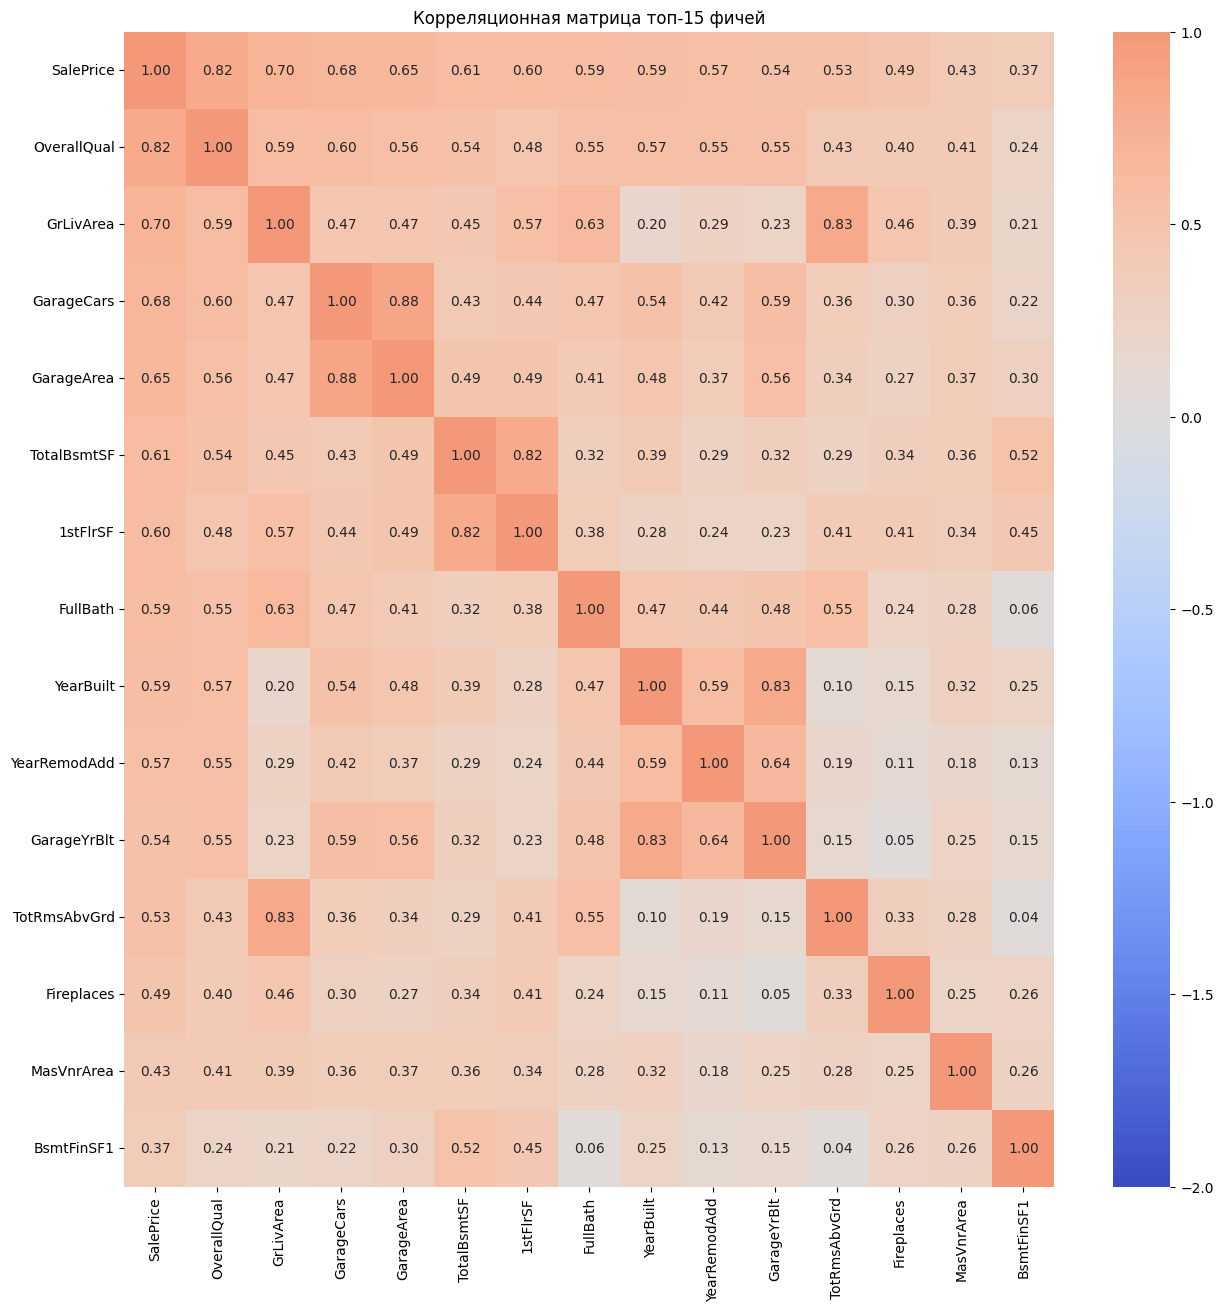

In [248]:
best_corr = corr['SalePrice'].nlargest(15)
plt.figure(figsize=(15,15))
sns.heatmap(corr.loc[best_corr.index, best_corr.index], 
            annot=True, cmap='coolwarm', fmt='.2f', center=0, vmin=-2, vmax=1)
plt.title('Корреляционная матрица топ-15 фичей')
plt.show()

Корреляционная матрица показывает мультиколлинеарность между: TotRmsAbvGrd и GrLivArea (0.83), YearBuilt и GarageYrBlt (0.83), 1stFlrSF и TotalBsmtSF (0.82), GarageCars и GarageArea (0.88). Для бустингов это не критично — деревья выберут лучший признак из пары при построении сплитов. На этапе feature engineering можно попробовать объединить некоторые пары.

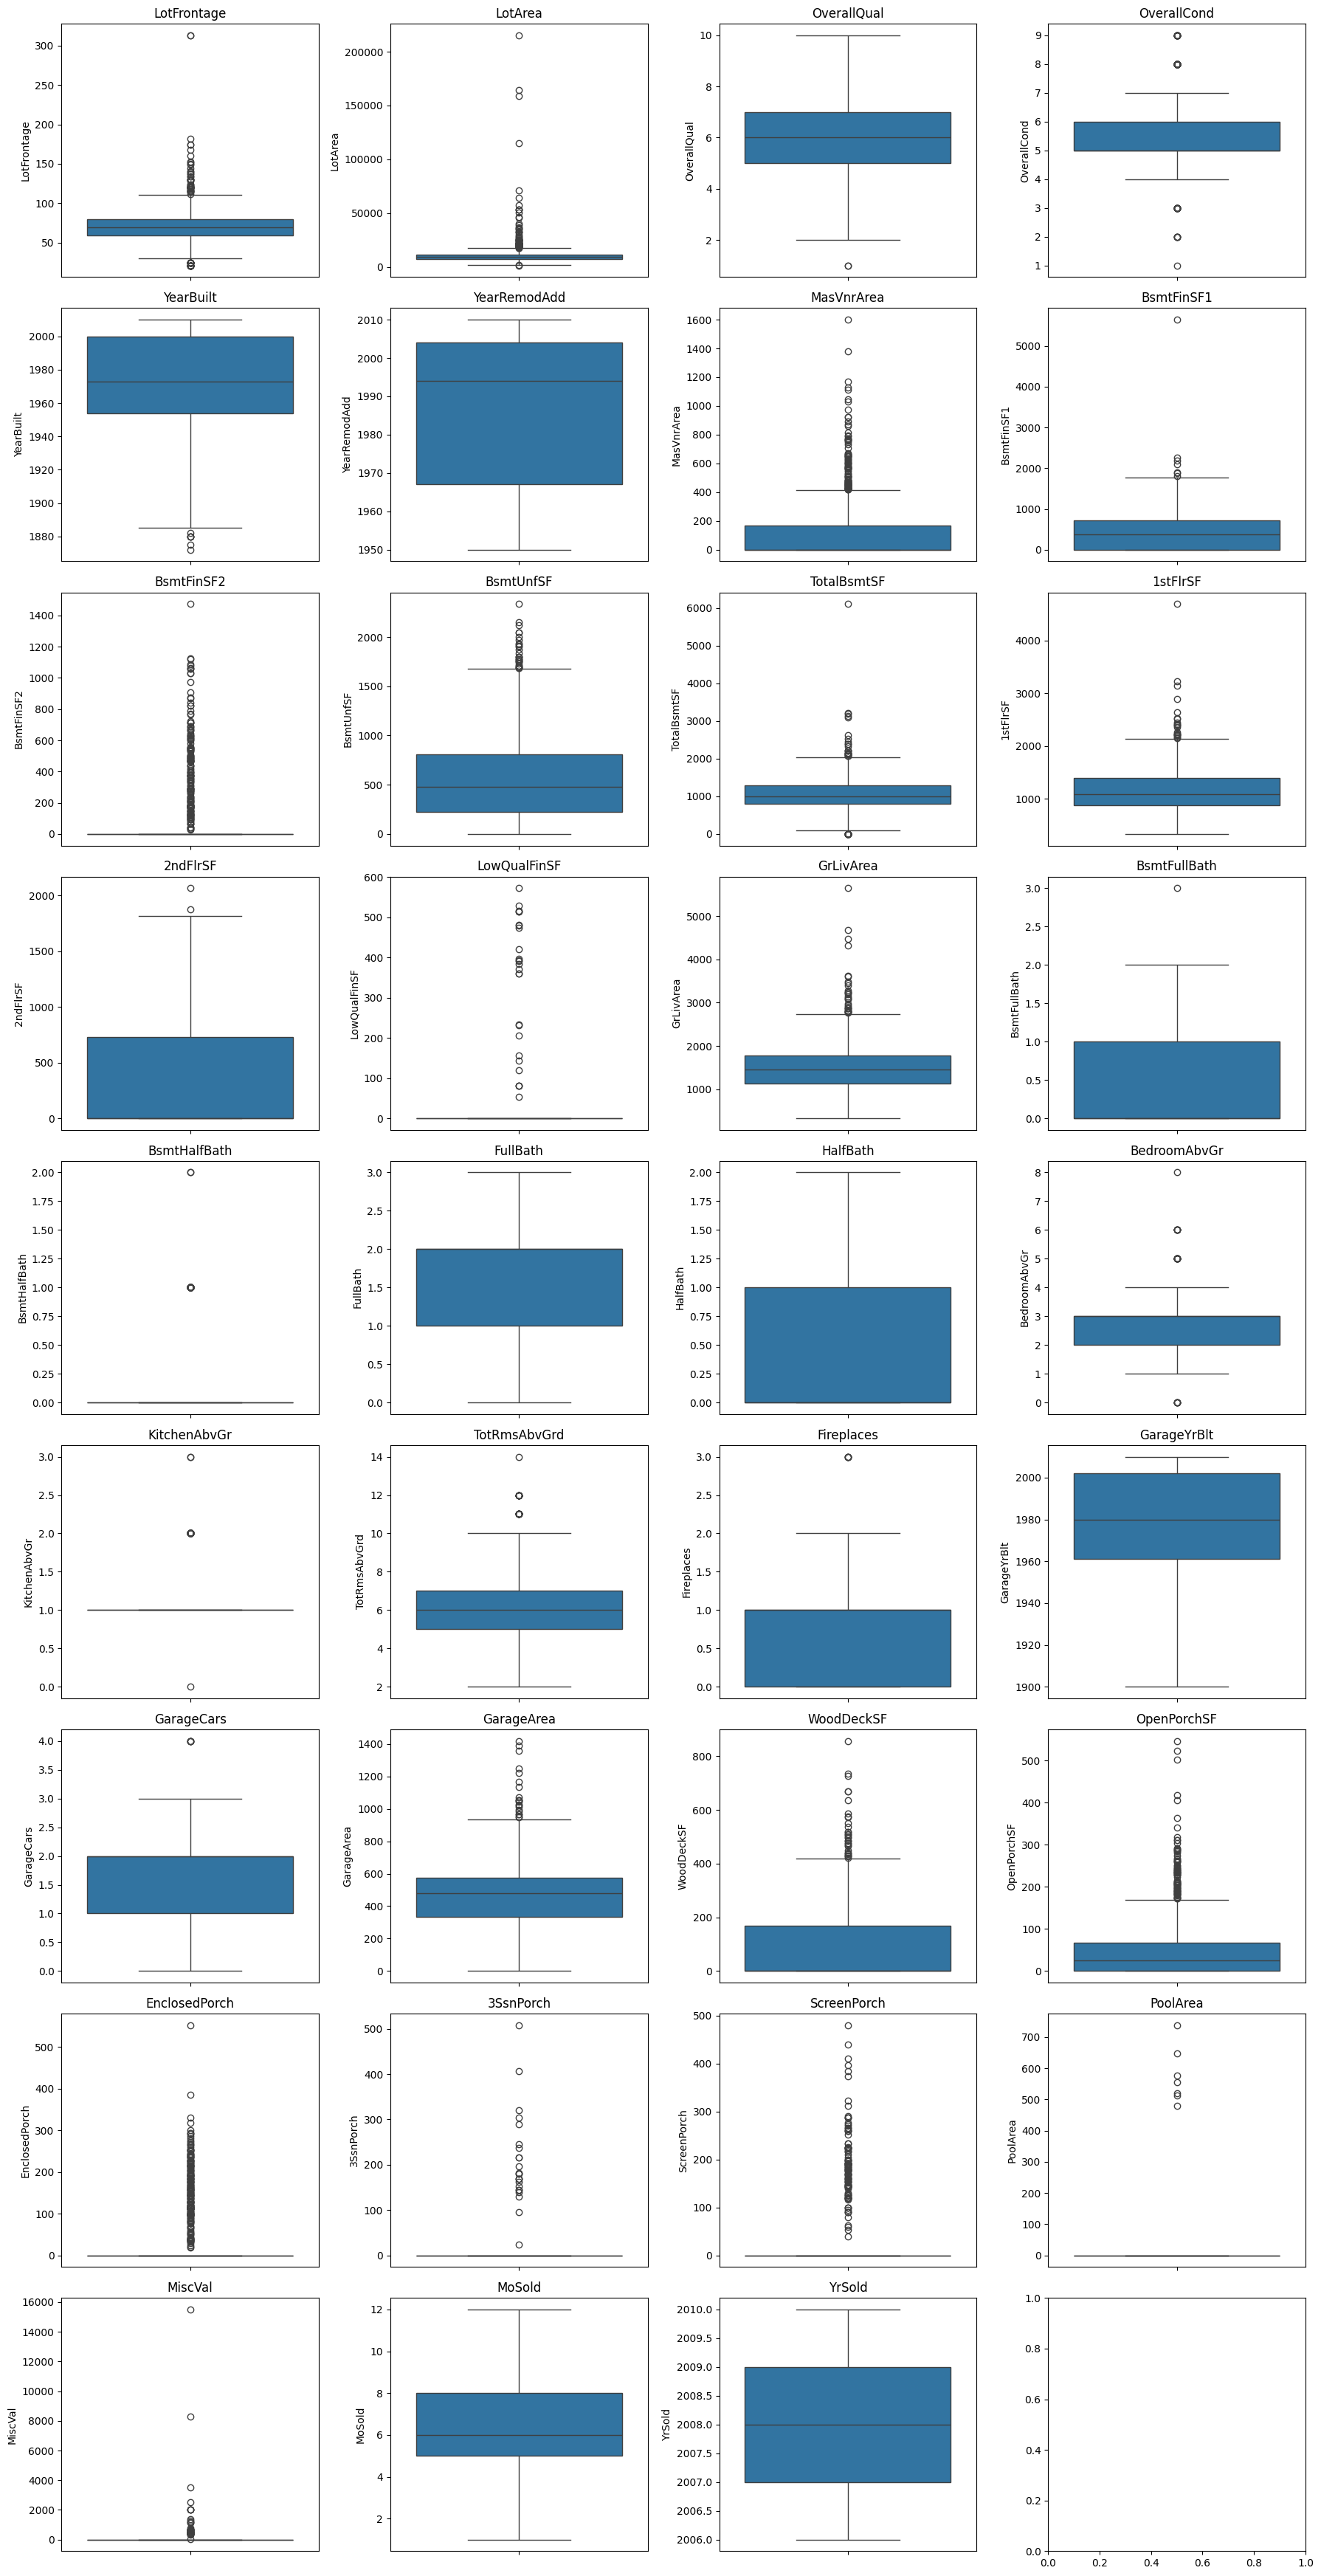

In [249]:
fig, axes = plt.subplots(9,4,figsize=(18,35))

for ax, col in zip(axes.flatten(), num_ftrs):
    sns.boxplot(data=train_df, y = col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

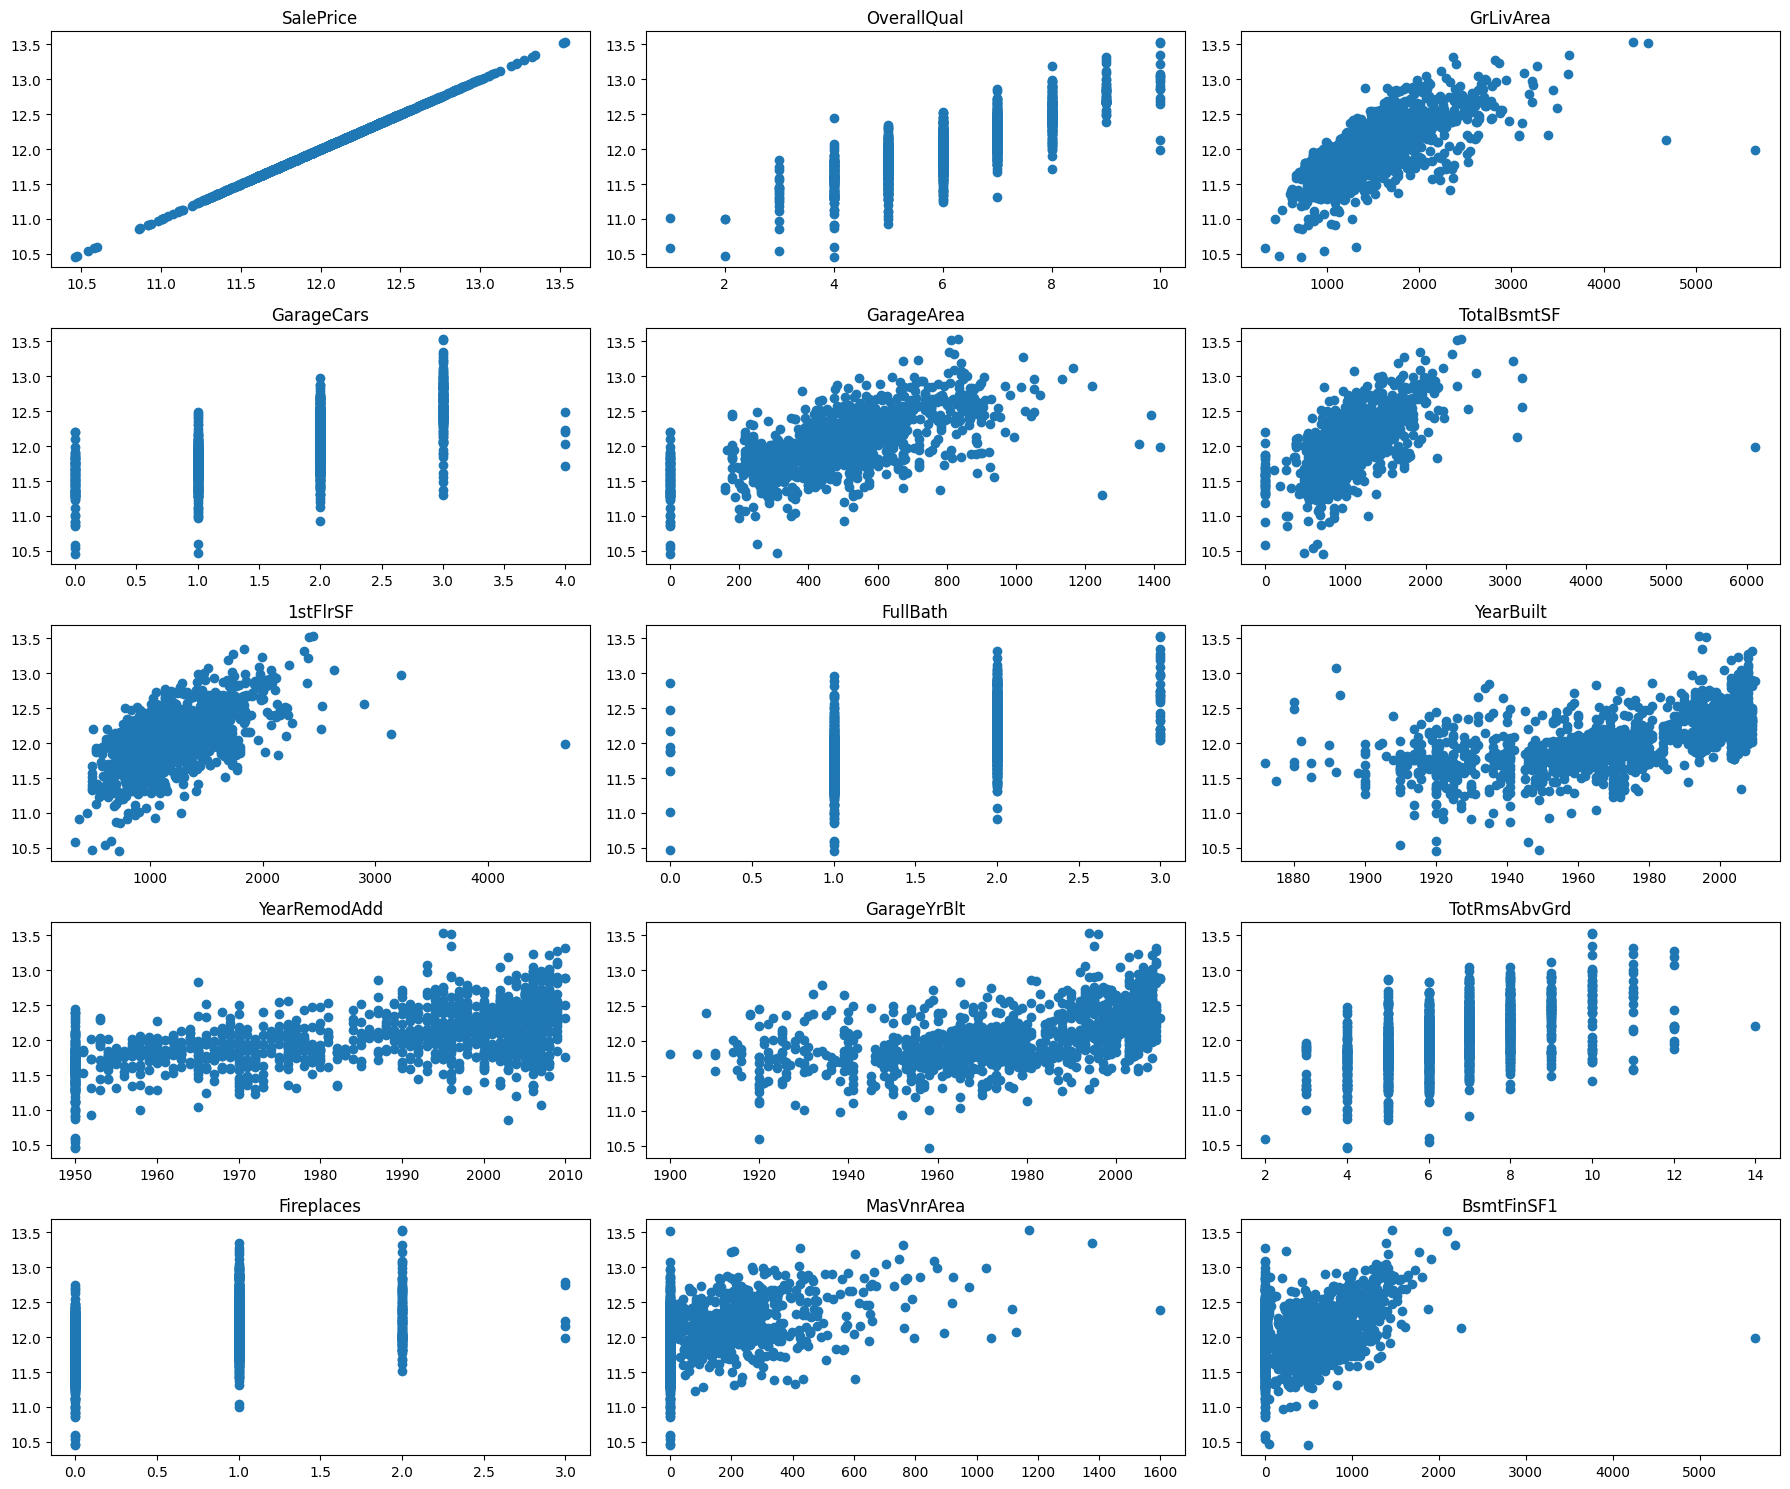

In [250]:
fig, axes = plt.subplots(5, 3, figsize=(18,15))
for ax, col in zip(axes.flatten(), best_corr.index):
    ax.scatter(train_df[col], train_df['SalePrice'])
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [251]:
train_df.loc[[524, 1299], best_corr.index] / train_df[best_corr.index].median()

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,YearRemodAdd,GarageYrBlt,TotRmsAbvGrd,Fireplaces,MasVnrArea,BsmtFinSF1
Id,,,,,,,,,,,,,,,
524,1.010436,1.666667,3.193989,1.5,1.841667,3.164902,2.886845,1.5,1.017233,1.007021,1.013636,1.833333,1.0,inf,5.89309
1299,0.998452,1.666667,3.853825,1.0,2.954167,6.162380,4.316467,1.0,1.017739,1.007021,1.014141,2.000000,3.0,inf,14.71708


In [252]:
train_df = train_df.drop(index=[524, 1299])
train_df.shape

(1458, 80)

Анализируя boxplots и scatters по топ-15 признакам удалось, найти два дома, площадь которых кратно больше медианной, а цена колеблется около медианной, что является аномалией, от которой следует избавиться. Семантически можно предположить, что это была сделка по низу рынка.

### Категориальные признаки

Категориальный EDA решает три вопроса:
1. Кардинальность - сколько уникальных категорий в каждом признаке. Признаки с 1-2 уникальными значениями почти бесполезны.
2. Редкие категории - есть ли категории с единичными наблюдениями. Категория с 1-2 объектами = проблемы при обучении/валидации
3. Связь с таргетом - влияние на целевую переменную.

In [253]:
print(len(cat_ftrs))
train_df[cat_ftrs].nunique().sort_values(ascending=False)

44


Neighborhood     25
Exterior2nd      16
Exterior1st      15
MSSubClass       15
Condition1        9
SaleType          9
HouseStyle        8
Condition2        8
RoofMatl          7
GarageType        7
BsmtFinType2      7
BsmtFinType1      7
Functional        7
Heating           6
SaleCondition     6
GarageCond        6
FireplaceQu       6
GarageQual        6
RoofStyle         6
Foundation        6
MiscFeature       5
Fence             5
BsmtExposure      5
ExterCond         5
BsmtQual          5
BldgType          5
LotConfig         5
MSZoning          5
Electrical        5
HeatingQC         5
BsmtCond          5
ExterQual         4
LandContour       4
LotShape          4
PoolQC            4
KitchenQual       4
GarageFinish      4
MasVnrType        3
Alley             3
LandSlope         3
PavedDrive        3
Street            2
Utilities         2
CentralAir        2
dtype: int64

Фичи Street, Utilities и CentralAir почти константы - нулевая информация.
Первые 4 фичи имеют слишком много уникальных значений для OHE. CatBoost с ними справится, а для остальных фреймворков лучше применить target encoding с защитой от target leakage (по аналогии с CatBoost).

In [254]:
for col in cat_ftrs:
    vc = train_df[col].value_counts()
    rare = vc[vc < 10]
    if len(rare) > 0:
        print(f'{col}: {rare.to_dict()}')

MSSubClass: {'40': 4}
Street: {'Grvl': 6}
LotShape: {'IR3': 9}
Utilities: {'NoSeWa': 1}
LotConfig: {'FR3': 4}
Neighborhood: {'NPkVill': 9, 'Blueste': 2}
Condition1: {'PosA': 8, 'RRNn': 5, 'RRNe': 2}
Condition2: {'Feedr': 6, 'Artery': 2, 'RRNn': 2, 'PosA': 1, 'PosN': 1, 'RRAn': 1, 'RRAe': 1}
HouseStyle: {'2.5Fin': 8}
RoofStyle: {'Mansard': 7, 'Shed': 2}
RoofMatl: {'WdShngl': 6, 'WdShake': 5, 'Metal': 1, 'Membran': 1, 'Roll': 1}
Exterior1st: {'BrkComm': 2, 'Stone': 2, 'AsphShn': 1, 'ImStucc': 1, 'CBlock': 1}
Exterior2nd: {'Brk Cmn': 7, 'Stone': 5, 'AsphShn': 3, 'Other': 1, 'CBlock': 1}
ExterCond: {'Ex': 3, 'Po': 1}
Foundation: {'Stone': 6, 'Wood': 3}
BsmtCond: {'Po': 2}
Heating: {'Grav': 7, 'Wall': 4, 'OthW': 2, 'Floor': 1}
HeatingQC: {'Po': 1}
Electrical: {'FuseP': 3, 'Mix': 1}
Functional: {'Maj2': 5, 'Sev': 1}
GarageType: {'CarPort': 9, '2Types': 6}
GarageQual: {'Ex': 3, 'Po': 3}
GarageCond: {'Gd': 9, 'Po': 7, 'Ex': 2}
PoolQC: {'Ex': 2, 'Fa': 2, 'Gd': 2}
MiscFeature: {'Gar2': 2, 'Othr'

При кросс-валидации редкая категория может попасть в val-фолд = проблема при кодировании, потому для редких категорий с менее 5 элементами будем выводить общую категорию Other.

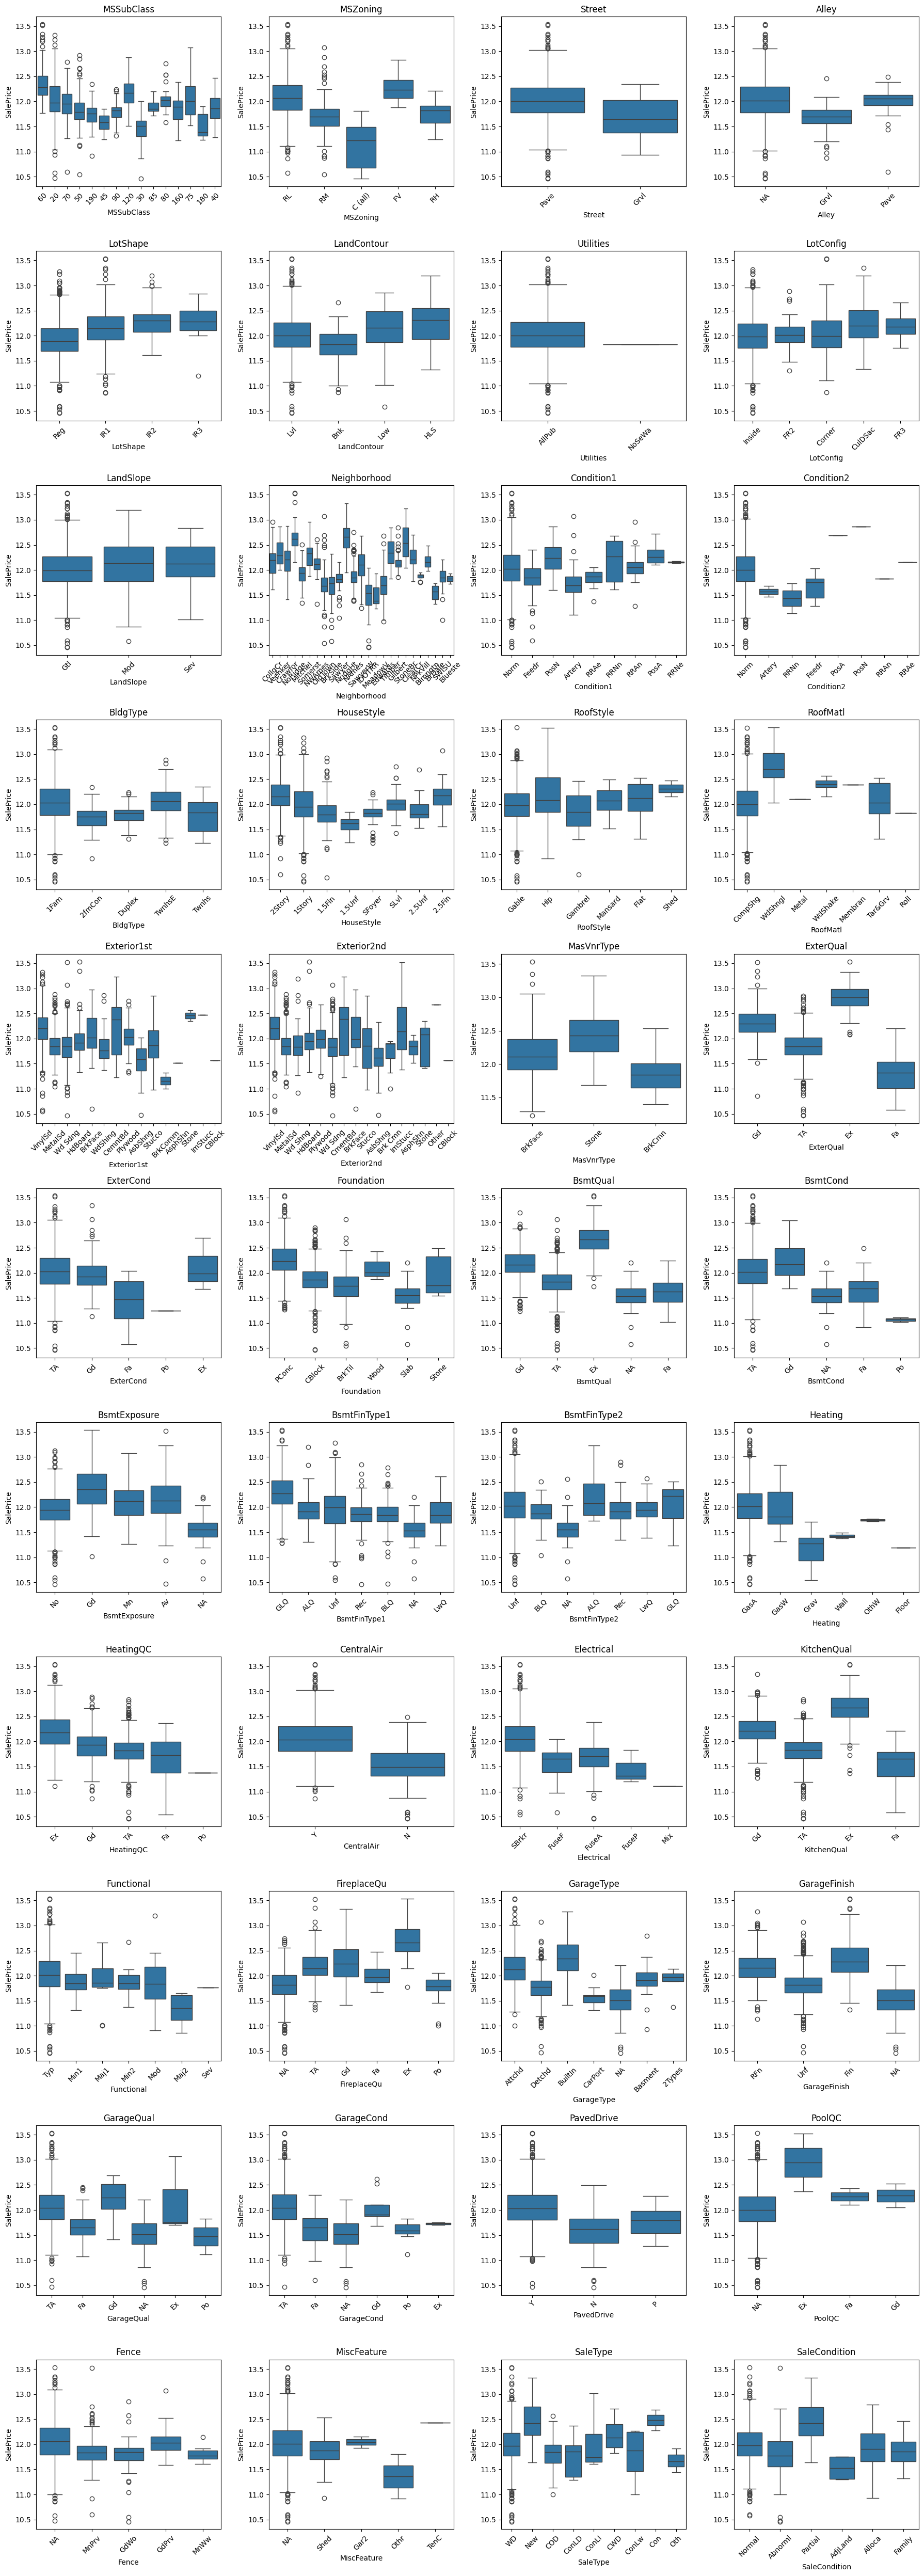

In [255]:
fig, axes = plt.subplots(11,4,figsize=(18,50))
for ax, col in zip(axes.flatten(), cat_ftrs):
    sns.boxplot(data=train_df, x=col, y='SalePrice', ax=ax)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Наиболее важными являются признаки, боксплоты которых находятся на разных уровнях:
1. Neighborhood
2. Качественные признаки "...Qual", "...Cond", "...QC"

## 2. Feature Engineering & Preprocessing
<a id="preprocessing"></a>

Начинаем с импутаций NaN'ов

In [256]:
missed_values = train_df.isna().sum()[train_df.isna().sum() > 0]
for i in missed_values.index:
    print(i, train_df[i].dtype, missed_values[i])

LotFrontage float64 259
MasVnrType str 872
MasVnrArea float64 8
Electrical str 1
GarageYrBlt float64 81


У нас имеется пять фичей с пропусками - два типа данных (str и float64).<br>
Сразу нужно упомянуть, что MasVnrType категориальная переменная, в которой имеется отдельная категория None, несущая в себе информацию, отсюда 872 NaN значения в датафрейме. Тут мы просто заполним NaN категорией "None".<br>
Electrical - категориальная фича с 1 пропуском по всему дфу, заполним модой.<br>
Остались числовые значения. По всем трем фичам анализ гистограмм показал сильный скос (несимметричное) распределение данных, тогда заполняем медианой, более устойчивой к выбросам. Однако, нужно упомянуть, что GarageYrBuilt стоит рассматривать как категориальную переменную, а не числовую, при этом NaN это не пропуск, а информация, что у дома нет гаража. В таком случае лучше всего подойдет значение 0, указывающее на отсутствие гаража.

In [257]:
train_df['MasVnrType'] = train_df['MasVnrType'].fillna("None")
train_df['Electrical'] = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df['LotFrontage'].median())
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(train_df['MasVnrArea'].median())
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna(0)

test_df['MasVnrType'] = test_df['MasVnrType'].fillna("None")
test_df['Electrical'] = test_df['Electrical'].fillna(train_df['Electrical'].mode()[0])
test_df['LotFrontage'] = test_df['LotFrontage'].fillna(train_df['LotFrontage'].median())
test_df['MasVnrArea'] = test_df['MasVnrArea'].fillna(train_df['MasVnrArea'].median())
test_df['GarageYrBlt'] = test_df['GarageYrBlt'].fillna(0)

Мультикорреляция:<br>
TotRmsAbvGrd и GrLivArea (0.83) - разные измерения<br>
YearBuilt и GarageYrBlt (0.83) - сливать не нужно, бустинг сам выберет лучшую фичу<br>
1stFlrSF и TotalBsmtSF (0.82) - новый признак TotalSF, равный сумме всей площади<br>
GarageCars и GarageArea (0.88) - разные измерения<br>
YrSold и YearBuilt - новый признак HouseAge равный разнице<br>
YrSold и YearRemodAdd - новый признак RemodAge равный разнице

In [258]:
train_df['HasPool'] = train_df['PoolArea'] != 0
train_df['TotalSF'] = train_df.TotalBsmtSF + train_df['1stFlrSF'] + train_df['2ndFlrSF']
train_df['HouseAge'] = train_df.YrSold - train_df.YearBuilt
train_df['RemodAge'] = train_df.YrSold - train_df.YearRemodAdd

test_df['HasPool'] = test_df['PoolArea'] != 0
test_df['TotalSF'] = test_df.TotalBsmtSF + test_df['1stFlrSF'] + test_df['2ndFlrSF']
test_df['HouseAge'] = test_df.YrSold - test_df.YearBuilt
test_df['RemodAge'] = test_df.YrSold - test_df.YearRemodAdd

Переходим к кодированию категориальных признаков.<br>
1. Вспомним, что категории Street, Utilities и CentralAir имеют 2 категории и несут почти нулевую информацию.
2. Редкие категории должны слиться в категорию Other

In [259]:
# Для catboost у нас имеется фича cat_ftrs

train_df.drop(columns=['Street', 'Utilities', 'CentralAir'], inplace=True)
test_df.drop(columns=['Street', 'Utilities', 'CentralAir'], inplace=True)
cat_ftrs = [i for i in train_df if train_df[i].dtype=='str']
print(cat_ftrs)

['MSSubClass', 'MSZoning', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [260]:
for col in cat_ftrs:
    rare = train_df[col].value_counts()
    rare = rare[rare < 5].index.to_list()
    train_df[col] = train_df[col].replace(rare, 'Other')
    test_df[col] = test_df[col].replace(rare, 'Other')

    known = set(train_df[col].unique())
    test_df[col] = test_df[col].where(test_df[col].isin(known), 'Other')

Чтобы избежать утечки, берем rare только по train_df. Также обрабатываем в test категории, которые могли не появится в train_df.

In [261]:
# Фичи с подписью Qual и Cond имеют свой собственный порядок категорий + др. порядковые фичи -> Ordinal Encoding
# Фичи до 10 категорий -> OHE
# Остальное -> Target Encoding с защитой от target leakage
print(cat_ftrs) # Семантический поиск порядковых признаков

qual_cond_map = {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
lotshape_map = {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0}
landslope_map = {'Gtl': 2, 'Mod': 1, 'Sev': 0}
bsmtexp_map = {'NA': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
bsmttype_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0}
garage_map = {'NA': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
paveddrive_map = {'N': 0, 'P': 1, 'Y': 2}

ord_maps = {
    'LotShape':    lotshape_map,
    'LandSlope':   landslope_map,
    'ExterQual':   qual_cond_map,
    'ExterCond':   qual_cond_map,
    'BsmtQual':    qual_cond_map,
    'BsmtCond':    qual_cond_map,
    'BsmtExposure': bsmtexp_map,
    'BsmtFinType1': bsmttype_map,
    'BsmtFinType2': bsmttype_map,
    'HeatingQC':   qual_cond_map,
    'KitchenQual': qual_cond_map,
    'FireplaceQu': qual_cond_map,
    'GarageFinish': garage_map,
    'GarageQual':  qual_cond_map,
    'GarageCond':  qual_cond_map,
    'PavedDrive':  paveddrive_map,
    'PoolQC':      qual_cond_map,
}

# После Ordinal Encoding фреймворки принимают разные датафреймы 
train_cb, train_gb, test_cb, test_gb = train_df.copy(), train_df.copy(), test_df.copy(), test_df.copy()
cb_cat_ftrs = cat_ftrs.copy()

for col, mapping in ord_maps.items():
    train_gb[col] = train_gb[col].map(mapping).fillna(0)
    test_gb[col] = test_gb[col].map(mapping).fillna(0)

te_ftrs = [i for i in cat_ftrs if train_gb[i].nunique() > 10]
ohe_ftrs = [i for i in cat_ftrs if (i not in ord_maps) and (i not in te_ftrs)]

# OHE
train_gb = pd.get_dummies(train_gb, columns=ohe_ftrs)
test_gb = pd.get_dummies(test_gb, columns=ohe_ftrs)
test_gb = test_gb.reindex(columns=train_gb.drop(columns=['SalePrice']).columns, fill_value=0)

['MSSubClass', 'MSZoning', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [262]:
# Target Encoding
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for col in te_ftrs:
    train_gb[col + '_te'] = np.nan

    for train_idx, val_idx in kf.split(train_gb):
        means = train_gb.iloc[train_idx].groupby(col)['SalePrice'].mean()
        train_gb.loc[train_gb.iloc[val_idx].index, col + '_te'] = train_gb.iloc[val_idx][col].map(means)
    
    global_means = train_gb.groupby(col)['SalePrice'].mean()
    test_gb[col + '_te'] = test_gb[col].map(global_means)

    train_gb.drop(columns=[col], inplace=True)
    test_gb.drop(columns=[col], inplace=True)

    train_gb[col + '_te'] = train_gb[col + '_te'].fillna(train_gb['SalePrice'].mean())
    test_gb[col + '_te'] = test_gb[col + '_te'].fillna(train_gb['SalePrice'].mean())

Высококардинальные признаки (Neighborhood, Exterior и др.) кодируем через target encoding: каждая категория заменяется средним SalePrice по обучающей выборке.

Чтобы избежать утечки таргета в train, используем out-of-fold схему — на каждом объекте среднее считается только по остальным 4 фолдам, но не по фолду, где этот объект сам находится. Для test — глобальное среднее по всему train.

NaN после маппинга (категория не встречалась в train-фолде) заполняются глобальным средним.

На основе SHAP-анализа добавляем новые признаки для всех четырёх датафреймов (CatBoost и LightGBM):
- **QualSF** = OverallQual × TotalSF — взаимодействие качества и площади
- **TotalBath** = FullBath + 0.5×HalfBath + BsmtFullBath + 0.5×BsmtHalfBath — суммарные санузлы с логичными весами
- **TotalPorch** — суммарная площадь внешних зон (аналог TotalSF)
- **IsNew** — новостройка в год продажи, семантически особый сегмент рынка
- **OverallScore** = OverallQual × OverallCond — комплексная оценка: плохое состояние штрафует сильнее при высоком качестве

In [263]:
for df in [train_cb, test_cb, train_gb, test_gb]:
    df['QualSF']       = df['OverallQual'] * df['TotalSF']
    df['TotalBath']    = df['FullBath'] + 0.5*df['HalfBath'] + df['BsmtFullBath'] + 0.5*df['BsmtHalfBath']
    df['TotalPorch']   = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF']
    df['IsNew']        = (df['YearBuilt'] == df['YrSold']).astype(int)
    df['OverallScore'] = df['OverallQual'] * df['OverallCond']

## 3. Baseline — XGBoost (default params)
<a id='baseline'></a>

In [264]:
# XGBoost baseline

X_xgb, y_xgb = train_gb.drop(columns=['SalePrice']), train_gb['SalePrice']
X_train_xgb, X_val_xgb, y_train_xgb, y_val_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)
X_test_xgb = test_gb

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)

xgb_val_preds = xgb_model.predict(X_val_xgb)
print(f"RMSE (по логарифму таргета): {root_mean_squared_error(y_val_xgb, xgb_val_preds)}")

RMSE (по логарифму таргета): 0.14147077709874178


Мы получили весьма неплохую оценку для baseline RMSE=0.14090778080320668<br>
Переходим к построению основной модели

## 4. Основная модель — CatBoost/LightGBM с тюнингом
<a id='gb'></a>

### 4.1. CatBoost w/o Optuna
<a id='cb-base'></a>

In [265]:
X_cb, y_cb = train_cb.drop(columns=['SalePrice']), train_cb['SalePrice']
X_train_cb, X_val_cb, y_train_cb, y_val_cb = train_test_split(X_cb, y_cb, test_size=0.2, random_state=42)
X_test_cb = test_cb
for col in ['TotalSF', 'QualSF', 'TotalBath']:
    test_cb[col] = test_cb[col].fillna(0)
    test_gb[col] = test_gb[col].fillna(0)


cb_model = CatBoostRegressor(eta=0.03, max_depth=6, random_seed=42, cat_features=cb_cat_ftrs, iterations=2000, verbose=200)

cb_model.fit(X_train_cb, y_train_cb, eval_set=(X_val_cb, y_val_cb), early_stopping_rounds=50)
cb_val_preds = cb_model.predict(X_val_cb)

0:	learn: 0.3889479	test: 0.4026485	best: 0.4026485 (0)	total: 68.1ms	remaining: 2m 16s
200:	learn: 0.1032013	test: 0.1272720	best: 0.1272720 (200)	total: 15.5s	remaining: 2m 18s
400:	learn: 0.0834309	test: 0.1165459	best: 0.1165459 (400)	total: 32.3s	remaining: 2m 8s
600:	learn: 0.0710411	test: 0.1144021	best: 0.1143814 (597)	total: 49.2s	remaining: 1m 54s
800:	learn: 0.0617938	test: 0.1136640	best: 0.1136112 (792)	total: 1m 5s	remaining: 1m 38s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1135796058
bestIteration = 825

Shrink model to first 826 iterations.


### 4.2. CatBoost SHAP
<a id='cb-shap'></a>

In [266]:
# Для CatBoost лучше использовать встроенный метод Pool, а не shap.TreeExplainer. Он корректно обрабатывает категории.
val_pool = Pool(X_val_cb, label=y_val_cb, cat_features=cb_cat_ftrs)

# shape: (n_samples, n_features+1) - последний столбец содержит bias (base value)
raw_shap = cb_model.get_feature_importance(data=val_pool, type='ShapValues')
shap_values = raw_shap[:, :-1]
base_value = raw_shap[0, -1]

feature_names = X_val_cb.columns.tolist()

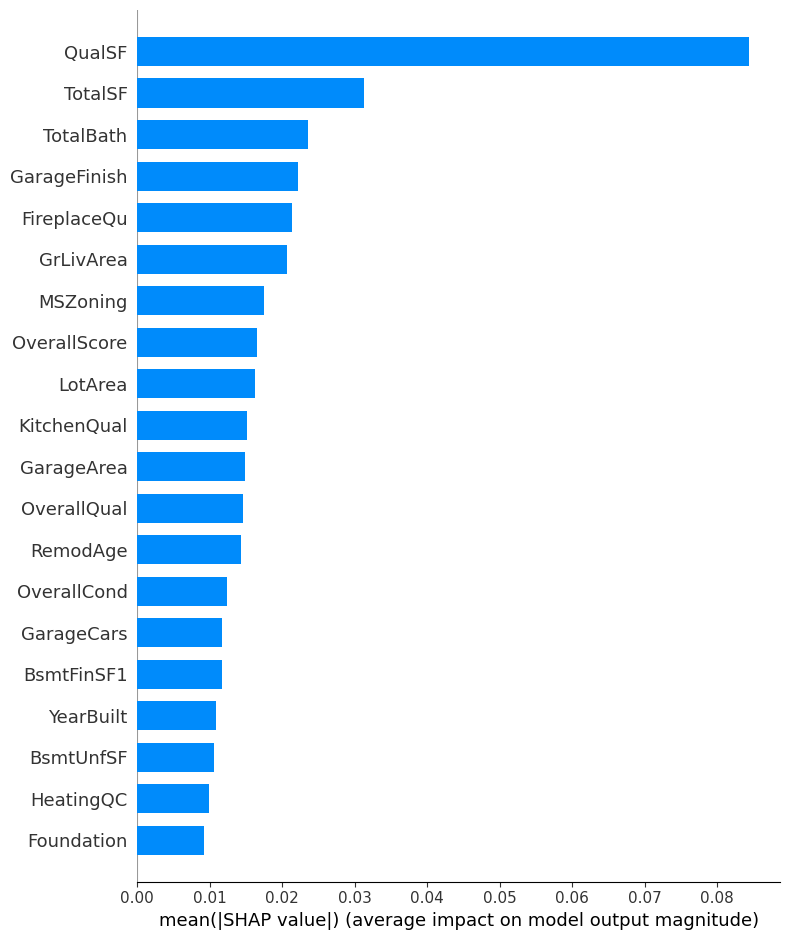

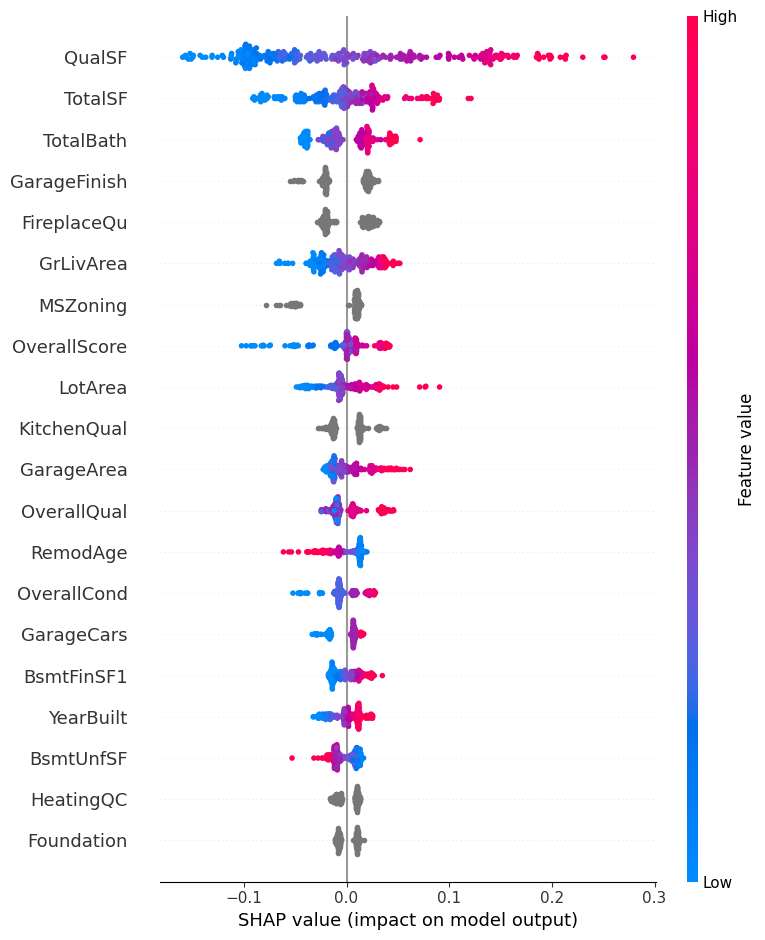

In [267]:
# Bar plot: общая важность (среднее |SHAP| по всем объектам)
shap.summary_plot(shap_values, X_val_cb, plot_type='bar', feature_names=feature_names)

# Beeswarm: важность + направление влияния каждой фичи
shap.summary_plot(shap_values, X_val_cb, feature_names=feature_names)

#### Анализ признаков (SHAP)
<a id="features"></a>

SHAP (SHapley Additive exPlanations) объясняет вклад каждого признака 
в каждое отдельное предсказание. Bar plot показывает среднее |SHAP| — 
общую важность. Beeswarm показывает направление: вправо = повышает цену, 
влево = понижает. Цвет точки = значение фичи (красный = высокое, синий = низкое).

##### Топ-признаки

**TotalSF (mean |SHAP| ≈ 0.08)** — наш инженерный признак (сумма 
TotalBsmtSF + 1stFlrSF + 2ndFlrSF) оказался важнее любого исходного 
признака датасета. Высокие значения (красные) сдвигают цену вправо 
до +0.25 в лог-масштабе. Это подтверждает правильность решения объединить 
площади этажей.

**OverallQual (≈ 0.052)** — общее качество дома на втором месте. 
Чёткая монотонная зависимость: высокое качество → правая часть, 
низкое → левая. Ordinal encoding с шагом 1-5 корректно передал порядок.

**GrLivArea (≈ 0.033)** — жилая площадь над землёй. Несмотря на то, 
что TotalSF её включает, GrLivArea всё равно несёт дополнительную 
информацию — модель использует оба признака.

##### Интересные наблюдения

**OverallCond асимметричен**: синие точки (плохое состояние) уходят 
далеко влево (до −0.15), тогда как красные (отличное состояние) едва 
достигают +0.05. Плохое состояние штрафует цену сильнее, чем хорошее 
её повышает.

**HouseAge (11-е место) vs YearBuilt (17-е место)**: инженерный признак 
возраста дома оказался информативнее исходного года постройки, хотя они 
высококоррелированы. Модель лучше обрабатывает относительный возраст, 
чем абсолютный год.

**Garage-кластер**: GarageFinish, GarageType, GarageArea, GarageCars 
суммарно влияют сильно, хотя каждый по отдельности уступает площадным 
признакам. Гараж — комплексный фактор цены.

**Neighborhood (13-е место)**: несмотря на высокую кардинальность (25 
категорий), target encoding сохранил информацию о районе. Серые точки 
указывают на малую дисперсию — большинство домов в средних районах, 
единичные выбросы дают сильный сигнал.

Идеи для Feature Engineering, основанные на SHAP и семантике:
1. QualSF = OverallQual * TotalSF — взаимодействие качества и площади. Дорогой дом = большой и качественный, простое умножение даёт это в одном признаке
2. TotalBath = FullBath + 0.5HalfBath + BsmtFullBath + 0.5BsmtHalfBath — все санузлы в одном признаке с логичными весами
3. TotalPorch = OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch + WoodDeckSF — по аналогии с TotalSF, суммарная площадь внешних зон
4. IsNew = YearBuilt == YrSold — новостройка в год продажи. Семантически особый сегмент рынка
5. OverallScore = OverallQual * OverallCond — SHAP показал, что OverallCond асимметричен: плохое состояние сильно штрафует. Произведение усилит этот эффект. Гипотеза для проверки

По результатам анализа SHAP выяснилось следующее:
1. QualSF оказался невероятно полезным признаком, занявшим топ-1 (как и предполагалось, исходя из важности обоих признаков, вошедших в него).
2. TotalBath - №3 признак - ожидаемо семантически, неожиданно по влиянию, входящих признаков. Судя по оценке, новая фича несет больше информации, чем входящие по отдельности.
3. OverallQual упал с №2 до №12 - ожидаемо, ведь QualSF и OverallScore отобрали от него самое лучшее.
4. OverallScore - №8 в списке важности фичей, гипотеза об ассиметрии подтвердилась - плохое состояние штрафует цену сильнее, чем хорошее прибавляет в ней.
5. В топ-20 фичей не попали TotalPorch и IsNew - относительно слабые признаки, не несут ни вреда, ни пользы, но для оптимизации можно удалить.

### 4.3. CatBoost w/ Optuna
<a id='cb-optuna'></a>

In [269]:
cb_kfold = KFold(n_splits=3, shuffle=True, random_state=42)
def objective(trial):
    params = {
        'iterations': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 7),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 5),
        'bootstrap_type': 'Bernoulli',
        'subsample': 0.8,
        'rsm': 0.8,  # random subspace method — субсэмплинг признаков
        'random_seed': 42,
        'cat_features': cb_cat_ftrs,
        'verbose': 0
    }

    scores = []
    for obj_train_idx, obj_val_idx in cb_kfold.split(train_cb):
        cb_optuna_model = CatBoostRegressor(**params)
        cb_optuna_model.fit(X_cb.iloc[obj_train_idx], y_cb.iloc[obj_train_idx],
                            eval_set = (X_cb.iloc[obj_val_idx], y_cb.iloc[obj_val_idx]),
                            early_stopping_rounds = 30)
        cb_optuna_preds = cb_optuna_model.predict(X_cb.iloc[obj_val_idx])
        scores.append(root_mean_squared_error(y_cb.iloc[obj_val_idx], cb_optuna_preds))
    return np.mean(scores)

# Нововведение, чтобы не считать результаты каждый раз
# ====================================================

import json, os

params_path = 'cb_best_params.json'
if os.path.exists(params_path):
    with open(params_path) as f:
        cb_best_params = json.load(f)
        print(cb_best_params)
else:
    cb_study = optuna.create_study(direction='minimize')
    cb_study.optimize(objective, n_trials=50)
    cb_best_params = cb_study.best_params
    with open(params_path, 'w') as f:
        json.dump(cb_best_params, f)
    print(cb_best_params)

[I 2026-05-11 22:45:03,240] A new study created in memory with name: no-name-533d8ed8-9aa2-4a93-9760-546f9a07d4e4
[I 2026-05-11 22:48:14,901] Trial 0 finished with value: 0.11707061146668436 and parameters: {'learning_rate': 0.025928839773451548, 'max_depth': 5, 'l2_leaf_reg': 1.8625325198609612}. Best is trial 0 with value: 0.11707061146668436.
[I 2026-05-11 22:55:24,268] Trial 1 finished with value: 0.11980762507120829 and parameters: {'learning_rate': 0.011727426017451621, 'max_depth': 7, 'l2_leaf_reg': 3.523170970101543}. Best is trial 0 with value: 0.11707061146668436.
[I 2026-05-11 22:58:24,224] Trial 2 finished with value: 0.11677339778519051 and parameters: {'learning_rate': 0.028155943783609087, 'max_depth': 5, 'l2_leaf_reg': 3.228292085435527}. Best is trial 2 with value: 0.11677339778519051.
[I 2026-05-11 23:04:12,447] Trial 3 finished with value: 0.11910119048054975 and parameters: {'learning_rate': 0.02148351524907803, 'max_depth': 7, 'l2_leaf_reg': 4.9104398521994055}. Be

{'learning_rate': 0.0215908916120117, 'max_depth': 5, 'l2_leaf_reg': 1.0837530765183536}


Лучшие параметры выводятся выше. Optuna с 5-fold CV выбирает параметры, устойчивые на всех разбиениях, а не только на одном сплите.

In [270]:
if 'cb_study' in globals():
    cb_best_value = cb_study.best_value
    print(f'CatBoost CV RMSE: {cb_best_value}')

CatBoost CV RMSE: 0.11576961592504137


### 4.4. LightGBM w/o Optuna
<a id='lgbm-base'></a>

In [271]:
train_gb['HasGarage'] = (train_gb['GarageArea'] > 0).astype('int')
test_gb['HasGarage'] = (test_gb['GarageArea'] > 0).astype('int')

X_lgbm = train_gb.drop(columns=['SalePrice'])
y_lgbm = train_gb['SalePrice']
X_train_lgbm, X_val_lgbm, y_train_lgbm, y_val_lgbm = train_test_split(X_lgbm, y_lgbm, test_size=0.2, random_state=42)
X_test_lgbm = test_gb

lgb_model = LGBMRegressor(learning_rate=0.03, max_depth=6, random_state=42, n_estimators=2000, verbose=-1)
lgb_model.fit(X_train_lgbm, y_train_lgbm, eval_set=[(X_val_lgbm, y_val_lgbm)],
              callbacks=[lgb.early_stopping(50, verbose=False)])

lgb_val_preds = lgb_model.predict(X_val_lgbm)
print(f"RMSE: {root_mean_squared_error(y_val_lgbm, lgb_val_preds)}")

RMSE: 0.13330276244045217


LightGBM на дефолтных параметрах уступает CatBoost — в первую очередь из-за того, что категориальные признаки обрабатываются через OHE/TE, тогда как CatBoost работает с ними нативно. Optuna должна подтянуть результат.

RMSE: 0.13270712874032356 - без пяти новых фичей<br>
RMSE: 0.13330276244045217 - после добавления

### 4.5. LightGBM w/ Optuna
<a id='lgbm-optuna'></a>

In [272]:
def objective_lgbm(trial):
    params = {'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
              'max_depth': trial.suggest_int('max_depth', 4, 10),
              'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
              'random_state': 42, 
              'n_estimators': 2000, 
              'verbose': -1}
    
    lgbm_scores = []
    for lgbm_train_idx, lgbm_val_idx in kf.split(train_gb):
        lgbm_optuna_model = LGBMRegressor(**params)
        lgbm_optuna_model.fit(X_lgbm.iloc[lgbm_train_idx], y_lgbm.iloc[lgbm_train_idx], eval_set=[(X_lgbm.iloc[lgbm_val_idx], y_lgbm.iloc[lgbm_val_idx])],
                            callbacks=[lgb.early_stopping(50, verbose=False)])
        lgbm_optuna_preds = lgbm_optuna_model.predict(X_lgbm.iloc[lgbm_val_idx])
        lgbm_scores.append(root_mean_squared_error(y_lgbm.iloc[lgbm_val_idx], lgbm_optuna_preds))
    return np.mean(lgbm_scores)

lgbm_params_path = 'lgbm_best_params.json'
if os.path.exists(lgbm_params_path):
    with open(lgbm_params_path) as f:
        lgbm_best_params = json.load(f)
        print(lgbm_best_params)
else:
    lgbm_study = optuna.create_study(direction='minimize')
    lgbm_study.optimize(objective_lgbm, n_trials=50)
    lgbm_best_params = lgbm_study.best_params
    lgbm_best_value = lgbm_study.best_value
    with open(lgbm_params_path, 'w') as f:
        json.dump(lgbm_best_params, f)
    print(lgbm_best_params)
    print(lgbm_best_value)

[I 2026-05-12 08:47:15,564] A new study created in memory with name: no-name-ab9f7779-1f02-4a73-aa01-6d6e8ddc7d7d
[I 2026-05-12 08:47:21,172] Trial 0 finished with value: 0.12421059397245697 and parameters: {'learning_rate': 0.015383723884437471, 'max_depth': 5, 'reg_lambda': 6.203100731582376}. Best is trial 0 with value: 0.12421059397245697.
[I 2026-05-12 08:47:26,734] Trial 1 finished with value: 0.12382730656639344 and parameters: {'learning_rate': 0.010792943946962395, 'max_depth': 4, 'reg_lambda': 8.680971671438904}. Best is trial 1 with value: 0.12382730656639344.
[I 2026-05-12 08:47:27,529] Trial 2 finished with value: 0.1261739446384164 and parameters: {'learning_rate': 0.22823019359532729, 'max_depth': 5, 'reg_lambda': 9.713019471065644}. Best is trial 1 with value: 0.12382730656639344.
[I 2026-05-12 08:47:31,713] Trial 3 finished with value: 0.1251975042044758 and parameters: {'learning_rate': 0.019790492220754678, 'max_depth': 8, 'reg_lambda': 5.502940687404774}. Best is tr

{'learning_rate': 0.04155078661532891, 'max_depth': 4, 'reg_lambda': 1.2960200913691056}
0.12240234382805708


LightGBM заметно уступает CatBoost по CV RMSE (~0.009 разрыв). Ансамбль 50/50 тянул бы результат вниз. Перебор весов на валидации даёт оптимальное соотношение в секции Submission.

### 4.6. ElasticNet

UPD: Не дождался завершения обучения CatBoost w/ Optuna, решил написать линейную модель. Выбор пал на ElasticNet в силу ее гибкости - L1+L2 регуляризации с параметром l1_ratio, контролирующим жесткость каждой. При значении l1_ratio близком к нулю, получаем модель близкую к Ridge, при близости к единице, получаем модель бликую к Lasso.

Для ElasticNet не нужно создавать отдельный датафрейм, подойдет дф от LightGBM - train_gb после Ordinal/OHE/TE, однако нужно будет провести масштабирование данных. Лучше всего для этой задачи подойдет RobustScaler, аналогичный StandardScaler (приводит среднее к 0 и стандартное отклонение к 1), но использующий медиану и квартили. В sklearn имеется две реализации: ElasticNet и ElasticNetCV. Второй в нашем случае лучше по той причине, что он автоматически перебирает alpha и l1_ratio (если передать список из его значений).

In [273]:
X_en, y_en = train_gb.drop(columns=['SalePrice']), train_gb['SalePrice']
X_train_en, X_val_en, y_train_en, y_val_en = train_test_split(X_en, y_en,
                                                              test_size=0.2,
                                                              random_state=42)

scaler = RobustScaler()
X_train_en_scaled = scaler.fit_transform(X_train_en)
X_val_en_scaled = scaler.transform(X_val_en)

en_model = ElasticNetCV(
    l1_ratio=[i for i in np.arange(0.3, 0.7, 0.01)],
    alphas=[i for i in np.arange(0.01, 0.1, 0.01)],
    cv=5,
    random_state=42,
    max_iter=10000
)
en_model.fit(X_train_en_scaled, y_train_en)
en_val_preds = en_model.predict(X_val_en_scaled)
print(f'RMSE: {root_mean_squared_error(y_val_en, en_val_preds)}')
print(f'alpha: {en_model.alpha_}, l1_ratio: {en_model.l1_ratio_}')

RMSE: 0.13010389621724644
alpha: 0.01, l1_ratio: 0.3


RMSE получилась достаточно высокой. Причина в том, что датасет House Prices имеет сильные линейные связи между фичами и таргетом. Alpha=0.0009 означает, что feature engineering был весьма качественный и модель почти не штрафует фичи. L1-ratio = 0.45 оказался почти посередине со скосом в сторону Гребня, по-видимому некоторые признаки действительно хотели обнуления.

## 5. Ансамбль из CatBoost + LightGBM + ElasticNet
<a id="#ensemble"></a>

Стоит сказать, что составление ансамбля ошибок имеет смысл, когда ошибки более слабой модели некоррелированы с остальными. Почему CatBoost и LightGBM, а не все три модели? Ответ заключается в первом предложении этого markdown'а - XGBoost и LightGBM работают на одних и тех же датафреймах и обрабатывают их одинаково, из-за чего их ошибки будут схожими. Поэтому нет никакого смысла тюнить XGBoost через Optuna, даже несмотря на то, что XGBoost по RMSE все равно не догонит LightGBM, который обычно быстрее и точнее на табличных данных.<br>
Для реального импрува диверсификации можно рассмотреть линейные модели в ансамбль - Ridge, Lasso, ElasticNet на тех же данных.<br>
Также для улучшения предсказаний в целом, можно применять Stacking, суть которого заключается в создании мета-модели, которая на вход получает предсказания базовых моделей (здесь это были бы CatBoost и LightGBM), а на выходе мета-модель решает кому и насколько верить. На этих предсказаниях мета-модель обучается так же, как обычная модель обучается на признаках. Почему это работает? Мета-модель адаптивна и гибка, в разных ситуациях она может доверять разным базовым моделям. Пример, CatBoost точнее на дорогих домах, а LightGBM - на дешевых. Перебор и дальнейший хардкод по весам этого не учитывает.

Таким образом, существует три наиболее важных метода импрува результатов (отсортированы по убыванию дельты качества):
1. Внесение в ансамбль Ridge/Lasso/ElasticNet
2. Более глубокий FE
3. Stacking

После 5-го сабмита, попробую добавить Ridge. Более глубокий FE проигнорирую в силу проблем со скоростью обучения CatBoost с Optuna (считает часами). Stacking реализовывать не умею - попробую сделать с Claude Code.

UPD: Не дождался завершения обучения катбуста, решил написать линейную модель. Выбор пал на ElasticNet в силу ее гибкости - L1+L2 регуляризации с параметром l1_ratio, контролирующим жесткость каждой. При значении l1_ratio близком к нулю, получаем модель близкую к Ridge, при близости к единице, получаем модель бликую к Lasso.

In [274]:
cb_final_model = CatBoostRegressor(
    **cb_best_params,
    iterations=2000,
    random_seed=42,
    cat_features=cb_cat_ftrs,
    verbose=0
)
cb_final_model.fit(X_train_cb, y_train_cb, eval_set=(X_val_cb, y_val_cb), early_stopping_rounds=50)

cb_full_model = CatBoostRegressor(
    **cb_best_params,
    iterations=cb_final_model.best_iteration_,
    random_seed=42,
    cat_features=cat_ftrs,
    verbose=100
)
cb_full_model.fit(X_cb, y_cb)

lgbm_final_model = LGBMRegressor(
    **lgbm_best_params,
    random_state=42, 
    n_estimators=2000, 
    verbose=-1
)
lgbm_final_model.fit(X_train_lgbm, y_train_lgbm,
                     eval_set=[(X_val_lgbm, y_val_lgbm)],
                     callbacks=[lgb.early_stopping(50, verbose=False)])

lgbm_full_model = LGBMRegressor(
    **lgbm_best_params,
    n_estimators=lgbm_final_model.best_iteration_,
    random_state=42,
    verbose=-1
)
lgbm_full_model.fit(X_lgbm, y_lgbm)

scaler_full = RobustScaler()
X_en_scaled = scaler_full.fit_transform(X_en)

test_gb = test_gb.fillna(0)
X_test_en = test_gb
X_test_en_scaled = scaler_full.transform(X_test_en)
en_full_model = ElasticNet(
    l1_ratio=en_model.l1_ratio_,
    alpha=en_model.alpha_,
    random_state=42,
    max_iter=10000
)
en_full_model.fit(X_en, y_en)

0:	learn: 0.3936483	total: 53.4ms	remaining: 38.2s
100:	learn: 0.1522683	total: 6.09s	remaining: 37.1s
200:	learn: 0.1161215	total: 12.4s	remaining: 31.7s
300:	learn: 0.1047290	total: 18.5s	remaining: 25.5s
400:	learn: 0.0967954	total: 24.5s	remaining: 19.3s
500:	learn: 0.0915845	total: 30.9s	remaining: 13.2s
600:	learn: 0.0873780	total: 37s	remaining: 7.08s
700:	learn: 0.0844152	total: 43.4s	remaining: 928ms
715:	learn: 0.0839230	total: 44.3s	remaining: 0us


c:\Users\Артем\Desktop\VUZ\Kaggle\House Prices\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.941e-01, tolerance: 2.328e-02
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",np.float64(0.01)
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",np.float64(0.3)
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [279]:
cb_final_val_preds = cb_final_model.predict(X_val_cb)
lgbm_final_val_preds = lgbm_final_model.predict(X_val_lgbm)
en_final_val_preds = en_full_model.predict(X_val_en_scaled)
all_preds = []
best_rmse = 1
best_w = (0, 0, 0)
for i in np.arange(0, 1, 0.05):
    for j in np.arange(0, 1-i+0.001, 0.05):
        en_w = 1 - i - j
        weighted = i*cb_final_val_preds + j*lgbm_final_val_preds + en_w*en_final_val_preds
        cur_rmse = root_mean_squared_error(y_val_cb, weighted)
        if cur_rmse < best_rmse:
            best_rmse = cur_rmse
            best_w = (i, j, en_w)
print(best_rmse, *best_w)

0.11649396031615615 0.9500000000000001 0.05 -6.938893903907228e-17


c:\Users\Артем\Desktop\VUZ\Kaggle\House Prices\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names
  warnings.warn(


In [278]:
best_rmse = 1
best_w = (0, 0)
for i in np.arange(0, 1.001, 0.01):
    weighted = i * cb_final_val_preds + (1-i) * lgbm_final_val_preds
    cur_rmse = root_mean_squared_error(y_val_cb, weighted)
    if cur_rmse < best_rmse:
        best_rmse = cur_rmse
        best_w = (i, 1-i)
print(best_rmse, best_w)


0.11640771237737589 (np.float64(1.0), np.float64(0.0))


Итог по ансамблю: ни LGBM, ни EN не дали прироста к чистому CatBoost на валидации — лучший вес CB всегда равен 1.0. ElasticNet с α=0.0009 сжимает предсказания на тесте и резко ухудшает score (0.15062). Лучший submission — #4, ансамбль 0.8×CB + 0.2×LGBM (0.12362).

## 6. Submission
<a id='submission'></a>

In [280]:
# test_preds_log = best_w[0] * cb_full_model.predict(X_test_cb) + best_w[1] * en_full_model.predict(X_test_en_scaled)
# test_preds = np.exp(test_preds_log)

test_preds_log = cb_full_model.predict(X_test_cb)
test_preds = np.exp(test_preds_log)

submission = pd.DataFrame({
    'Id': test_cb.index,
    'SalePrice': test_preds
})
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,115824.742223
1,1462,162223.675115
2,1463,179576.953249
3,1464,193797.697908
4,1465,189968.519751


| # | Изменение | Kaggle Score | Место |
|---|-----------|:------------:|:-----:|
| 1 | CatBoost baseline | 0.12894 | 1617 / 5015 |
| 2 | Обучение на всём трейне | 0.12768 | 1401 / 5015 |
| 3 | CatBoost + CV in Optuna | 0.12768 | 1405 / 5039 |
| 4 | Ансамбль 0.8×CB + 0.2×LGBM | 0.12362 | 817 / 5042 |
| 5 | CB + EN + 5 признаков (NaN баг) | 0.15062 | — |
| 6 | CB + EN, bugfix | 0.15062 | — |
| 7 | Только CatBoost (Optuna 5-fold) | 0.12409 | — |
| 8 | Только CatBoost (Optuna 3-fold) | 0.12453 | — |


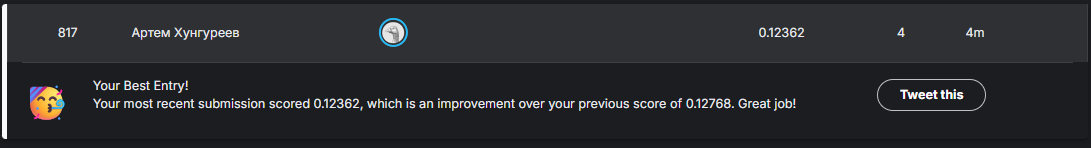

Итог: 816 / 5100 - top 16%